# Weak Identifiability Experiments 

Seven experiments that look at whether recovery failures in CTDS are caused by:
- **Optimisation / local optima** (EM gets stuck)
- **Statistical limits** (finite data / low SNR)
- **Structural non-identifiability** (the MLE genuinely moves away from truth)

| # | Exp |  Question |
|---|-----------|-------------|
| 1 | True-init vs ordinary-init | Are failures due to bad local optima? |
| 2 | Perturbation sensitivity | Which parameter directions are flat? |
| 3 | Profile likelihood / curvature | How curved is the objective in each direction? |
| 4 | E/I label-flip symmetry | Is E-vs-I asymmetry structural or SNR? |
| 5 | (D_E, D_I) dimension grid | Which dimension drives weak identifiability? |
| 6 | Multi-start EM | How much does EM solution vary across restarts? |
| 7 | Recovery vs sample size | Does more data fix recovery? |


In [1]:
# ============================================================
# CELL 1 — Imports & global configuration
# ============================================================
import jax
import jax.numpy as jnp
import jax.random as jr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from functools import partial
from itertools import product as iproduct

# --- project imports ---
from ctds.simulation_utils import (
    generate_synthetic_data,
    generate_CTDS_Params,
    transform_true_rec,
    save_figure,
    transform_true_rec_hungarian,
)
from ctds.models import CTDS
from ctds.params import (
    ParamsCTDS,
    ParamsCTDSInitial,
    ParamsCTDSDynamics,
    ParamsCTDSEmissions,
    ParamsCTDSConstraints,
)
from ctds.initialization import fa_initialize_ctds   # or pca_initialize_ctds — whichever you use

jax.config.update("jax_enable_x64", True)

# ── Global experiment parameters ─────────────────────────────
N          = 20    # number of neurons
T          = 2000   # timesteps per trial
B          = 5     # number of trials
D_BASE     = 4     # baseline latent dim
NUM_EM_ITERS = 80
EXP_GROUP  = 5     # passed to save_figure()

print("JAX devices:", jax.devices())
print(f"Baseline: N={N}, T={T}, B={B}, D={D_BASE}, EM iters={NUM_EM_ITERS}")


JAX devices: [CpuDevice(id=0)]
Baseline: N=20, T=2000, B=5, D=4, EM iters=80


In [2]:
# ============================================================
# CELL 2 — Shared helper functions
# ============================================================

def spectral_radius(A):
    """Largest absolute eigenvalue of A."""
    return float(jnp.max(jnp.abs(jnp.linalg.eigvals(A))))


def align_and_error(A_true, A_fit, C_true, C_fit, params_true):
    """
    Use transform_true_rec to align fitted params to true params,
    then return Frobenius errors for A and C.
    list_of_dimensions shape expected by transform_true_rec: (1, K).
    """
    ctd = params_true.constraints
    list_of_dims = jnp.array(ctd.cell_type_dimensions)[None, :]  # (1, K)
    try:
        """
        C_al, A_al, Q_al = transform_true_rec(
            C_true, C_fit, A_fit,
            jnp.zeros_like(A_fit),   # Q placeholder – not used for error
            list_of_dims
        )
        """
        align_result = transform_true_rec_hungarian(
                        C_true=np.array(C_true),
                        C_rec=np.array(C_fit),
                        A_rec=np.array(A_fit),
                        Q_rec=np.zeros_like(A_fit),
                        list_of_dimensions=list_of_dims,   
                        region_identity=None,                             
                        dead_thresh=1e-6,
                        use_abs_corr=True,
                        verbose=False)
        C_al = align_result["C_aligned"]
        A_al = align_result["A_aligned"]
        err_A = float(jnp.linalg.norm(A_al - A_true, 'fro'))
        err_C = float(jnp.linalg.norm(C_al - C_true, 'fro'))
    except Exception as e:
        print(f"  [align_and_error] alignment failed: {e}")
        err_A = float(jnp.linalg.norm(A_fit - A_true, 'fro'))
        err_C = float(jnp.linalg.norm(C_fit - C_true, 'fro'))
    return err_A, err_C



def fit_ctds(ctds, params_init, obs, num_iters=NUM_EM_ITERS):
    """
    Thin wrapper around ctds.fit_em() that catches NaNs and returns
    (params_fit, log_probs, nan_flag).
    obs shape: (B, T, N).
    """
    try:
        params_fit, lps = ctds.fit_em(params_init, obs, num_iters=num_iters)
        nan_flag = bool(jnp.any(jnp.isnan(params_fit.dynamics.weights)))
        return params_fit, lps, nan_flag
    except Exception as e:
        print(f"  [fit_ctds] exception: {e}")
        return params_init, jnp.full(num_iters, jnp.nan), True





def eval_ll(ctds, params, obs):
    """Mean marginal log-prob over trials."""
    try:
        lls = jax.vmap(partial(ctds.marginal_log_prob, params))(obs)
        return float(jnp.mean(lls))
    except Exception:
        return float('nan')


def perturb_params(params_true, epsilon, key, mode='both'):
    """
    Return params_true with small perturbation added.
    mode: 'A_only' | 'C_only' | 'both'
    Signs are clamped to preserve Dale constraints.
    """
    k1, k2 = jr.split(key)
    A = params_true.dynamics.weights
    C = params_true.emissions.weights
    dm = params_true.dynamics.dynamics_mask

    if mode in ('A_only', 'both'):
        dA = epsilon * jr.normal(k1, A.shape)
        A_new = A + dA
        # Re-enforce off-diagonal signs (Dale's law)
        D = A.shape[0]
        for j in range(D):
            od = jnp.arange(D) != j
            if dm[j] == 1:
                A_new = A_new.at[od, j].set(jnp.maximum(A_new[od, j], 0.0))
            elif dm[j] == -1:
                A_new = A_new.at[od, j].set(jnp.minimum(A_new[od, j], 0.0))
    else:
        A_new = A

    if mode in ('C_only', 'both'):
        dC = epsilon * jr.normal(k2, C.shape)
        C_new = jnp.maximum(0.0, C + dC)
    else:
        C_new = C

    dynamics = ParamsCTDSDynamics(
        weights=A_new, cov=params_true.dynamics.cov,
        dynamics_mask=params_true.dynamics.dynamics_mask
    )
    emissions = ParamsCTDSEmissions(
        weights=C_new, cov=params_true.emissions.cov,
        bias=params_true.emissions.bias,
        emission_dims=params_true.emissions.emission_dims,
        left_padding_dims=params_true.emissions.left_padding_dims,
        right_padding_dims=params_true.emissions.right_padding_dims,
    )
    return ParamsCTDS(
        initial=params_true.initial,
        dynamics=dynamics,
        emissions=emissions,
        constraints=params_true.constraints,
        observations=params_true.observations,
    )

print("Helper functions defined.")


Helper functions defined.


---
## Sect 1: True-Init vs Ordinary-Init Recovery

**Question:** When recovery degrades as D grows, is that because EM is getting stuck in bad local optima, or because the model is weakly identified?




In [3]:
# ============================================================
# SECTION 1 — Data generation & fitting loop
# ============================================================
D_values = [2, 4, 6, 8, 10, 12]
#D_values=[2,4,6]
results_s1 = []

for D in D_values:
    print(f"\n── D = {D} ──────────────────────")
    key = jr.PRNGKey(D * 100)

    # 1a. Generate ground-truth data
    states, obs, ctds, params_true = generate_synthetic_data(
        num_samples=B, num_timesteps=T, state_dim=D, emission_dim=N, key=key
    )
    A_true = params_true.dynamics.weights
    C_true = params_true.emissions.weights

    # 1b. Ordinary-init fit
    print("  Fitting with ordinary init...")
    key_oi, key_ti = jr.split(key)
    p_ordinary = ctds.initialize(obs)
    pf_ord, lps_ord, nan_ord = fit_ctds(ctds, p_ordinary, obs)
    ll_ord = eval_ll(ctds, pf_ord, obs)
    err_A_ord, err_C_ord = align_and_error(A_true, pf_ord.dynamics.weights,
                                           C_true, pf_ord.emissions.weights, params_true)
    rho_ord = spectral_radius(pf_ord.dynamics.weights)
    print(f"  Ordinary: err_A={err_A_ord:.4f}, err_C={err_C_ord:.4f}, "
          f"ll={ll_ord:.4f}, rho={rho_ord:.4f}, nan={nan_ord}")

    # 1c. True-init fit (tiny perturbation of ground truth)
    print("  Fitting from true init...")
    p_true_init = params_true
    pf_true, lps_true, nan_true = fit_ctds(ctds, p_true_init, obs)
    ll_true = eval_ll(ctds, pf_true, obs)
    err_A_true, err_C_true = align_and_error(A_true, pf_true.dynamics.weights,
                                              C_true, pf_true.emissions.weights, params_true)
    rho_true = spectral_radius(pf_true.dynamics.weights)
    print(f"  True-init: err_A={err_A_true:.4f}, err_C={err_C_true:.4f}, "
          f"ll={ll_true:.4f}, rho={rho_true:.4f}, nan={nan_true}")

    results_s1.append(dict(
        D=D,
        err_A_ord=err_A_ord, err_C_ord=err_C_ord, ll_ord=ll_ord,
        rho_ord=rho_ord, nan_ord=nan_ord,
        err_A_true=err_A_true, err_C_true=err_C_true, ll_true=ll_true,
        rho_true=rho_true, nan_true=nan_true,
        lps_ord=np.array(lps_ord), lps_true=np.array(lps_true),
        A_true=np.array(A_true),
        A_fit_ord=np.array(pf_ord.dynamics.weights),
        A_fit_true=np.array(pf_true.dynamics.weights),
    ))

print("\nSection 1 fitting complete.")



── D = 2 ──────────────────────
  Fitting with ordinary init...
Y shape (10000, 20)


Running for 80 iterations:   0%|          | 0/80 [00:00<?, ?it/s]

  Ordinary: err_A=0.0169, err_C=0.0357, ll=67836.4510, rho=0.9492, nan=False
  Fitting from true init...


Running for 80 iterations:   0%|          | 0/80 [00:00<?, ?it/s]

  True-init: err_A=0.0094, err_C=0.0366, ll=67873.7919, rho=0.9488, nan=False

── D = 4 ──────────────────────
  Fitting with ordinary init...
Y shape (10000, 20)


...

  True-init: err_A=0.1709, err_C=0.1804, ll=71491.1588, rho=0.9499, nan=False

── D = 12 ──────────────────────
  Fitting with ordinary init...
Y shape (10000, 20)


Running for 80 iterations:   0%|          | 0/80 [00:00<?, ?it/s]

  Ordinary: err_A=4.8854, err_C=2.8964, ll=82594.3567, rho=0.9495, nan=False
  Fitting from true init...


Running for 80 iterations:   0%|          | 0/80 [00:00<?, ?it/s]

  True-init: err_A=0.2774, err_C=0.2056, ll=82741.2627, rho=0.9483, nan=False

Section 1 fitting complete.


# Output for N=20.
Behaviour: At D=6 it takes ~65 iterations to explode. At D=8 it takes ~47. At D=10 it takes ~34.
Analysis: With N=20 neurons fixed and D growing, EM enterS a under-determined regime (D > N for D≥10 here, though N=50 in your setup based on earlier code). The moment the latent dimension exceeds the observation dimension, the M-step for Q is trying to estimate a D×D matrix from rank-N observations, making the sufficient statistics M_{1,T} rank-deficient

NameError: name 'COL_ORD' is not defined

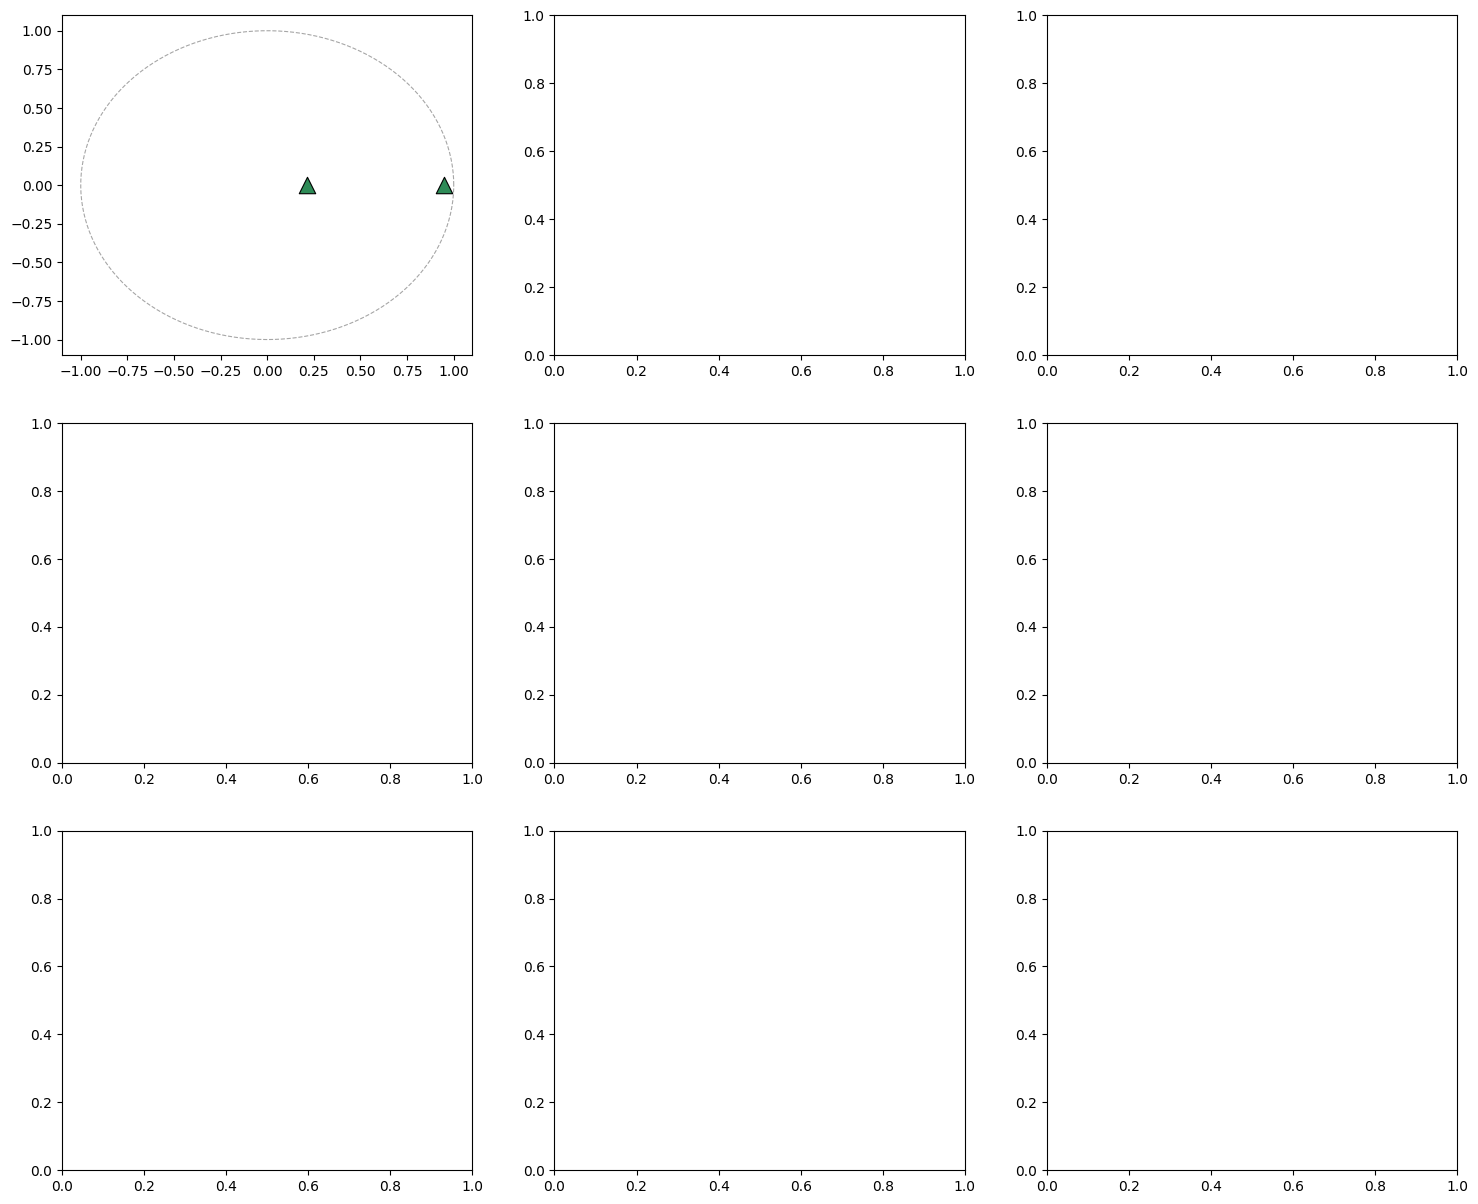

In [ ]:
# ============================================================
# Figure: Eigenvalue comparison — 3×3 grid layout
# ============================================================
Ds_eig = [r for r in results_s1 if r['D'] <= 12]
theta  = np.linspace(0, 2 * np.pi, 300)
nrows, ncols = 3, 3

# ── Panel 1: complex plane ───────────────────────────────────
fig1, axes1 = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes1_flat = axes1.ravel()

handles_labels = {}
for i, r in enumerate(Ds_eig):
    ax = axes1_flat[i]
    D = r['D']
    eig_true = np.linalg.eigvals(r['A_true'])
    eig_ord  = np.linalg.eigvals(r['A_fit_ord'])
    eig_ti   = np.linalg.eigvals(r['A_fit_true'])

    ax.plot(np.cos(theta), np.sin(theta), 'k--', lw=0.8, alpha=0.35)
    h1 = ax.scatter(eig_true.real, eig_true.imag, marker='^', s=140,
                    color='seagreen', zorder=5, edgecolors='k', lw=0.8, label='True A')
    h2 = ax.scatter(eig_ord.real,  eig_ord.imag,  marker='o', s=90,
                    color='orange',  zorder=4, edgecolors='k', lw=0.8, alpha=0.85, label='Ordinary init')
    h3 = ax.scatter(eig_ti.real,   eig_ti.imag,   marker='s', s=90,
                    color='green', zorder=4, edgecolors='k', lw=0.8, alpha=0.85, label='True init')
    for h in [h1, h2, h3]:
        handles_labels[h.get_label()] = h

    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.set_aspect('equal')
    ax.set_xlabel('Re(λ)');  ax.set_ylabel('Im(λ)')
    ax.set_title(f'D={D}');  ax.grid(alpha=0.2)

for j in range(len(Ds_eig), nrows * ncols):
    axes1_flat[j].set_visible(False)

fig1.suptitle('Eigenvalue comparison: complex plane\n',
              fontsize=14, fontweight='bold')
fig1.legend(handles=list(handles_labels.values()), labels=list(handles_labels.keys()),
            loc='upper center', ncol=3, fontsize=11,
            bbox_to_anchor=(0.5, 0.97), frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.93])  # leave room at top for title + legend
plt.savefig("fig_eigenvalues_complex_plane.png", bbox_inches='tight')
plt.show()

# ── Panel 2: sorted eigenvalue magnitudes ────────────────────
fig2, axes2 = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
axes2_flat = axes2.ravel()

for i, r in enumerate(Ds_eig):
    ax = axes2_flat[i]
    D = r['D']
    mag_true = np.sort(np.abs(np.linalg.eigvals(r['A_true'])))[::-1]
    mag_ord  = np.sort(np.abs(np.linalg.eigvals(r['A_fit_ord'])))[::-1]
    mag_ti   = np.sort(np.abs(np.linalg.eigvals(r['A_fit_true'])))[::-1]

    xi = np.arange(D);  w = 0.25
    ax.bar(xi - w, mag_true, w, color='seagreen', alpha=0.85, label='True A',       edgecolor='k', lw=0.6)
    ax.bar(xi,     mag_ord,  w, color='orange',   alpha=0.85, label='Ordinary init', edgecolor='k', lw=0.6)
    ax.bar(xi + w, mag_ti,   w, color='green',  alpha=0.85, label='True init',     edgecolor='k', lw=0.6)

    ax.axhline(1.0, color='gray', ls='--', lw=1, alpha=0.6)
    ax.set_xticks(xi);  ax.set_xticklabels([f'λ_{j+1}' for j in range(D)])
    ax.set_ylabel('|λ|');  ax.set_title(f'D={D}');  ax.grid(alpha=0.25, axis='y')

for j in range(len(Ds_eig), nrows * ncols):
    axes2_flat[j].set_visible(False)

fig2.suptitle('Eigenvalue magnitudes (sorted): true vs fitted A\n',
              fontsize=14, fontweight='bold')
# pull legend from first axis
handles, labels = axes2_flat[0].get_legend_handles_labels()
fig2.legend(handles, labels, loc='lower center', ncol=3, fontsize=11,
            bbox_to_anchor=(0.5, 0.01), frameon=True)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("fig_eigenvalues_magnitudes.png", bbox_inches='tight')
plt.show()

/var/folders/wp/bdnctj2s0s52y843dzp1kq_h0000gn/T/ipykernel_6001/1383751631.py:119: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


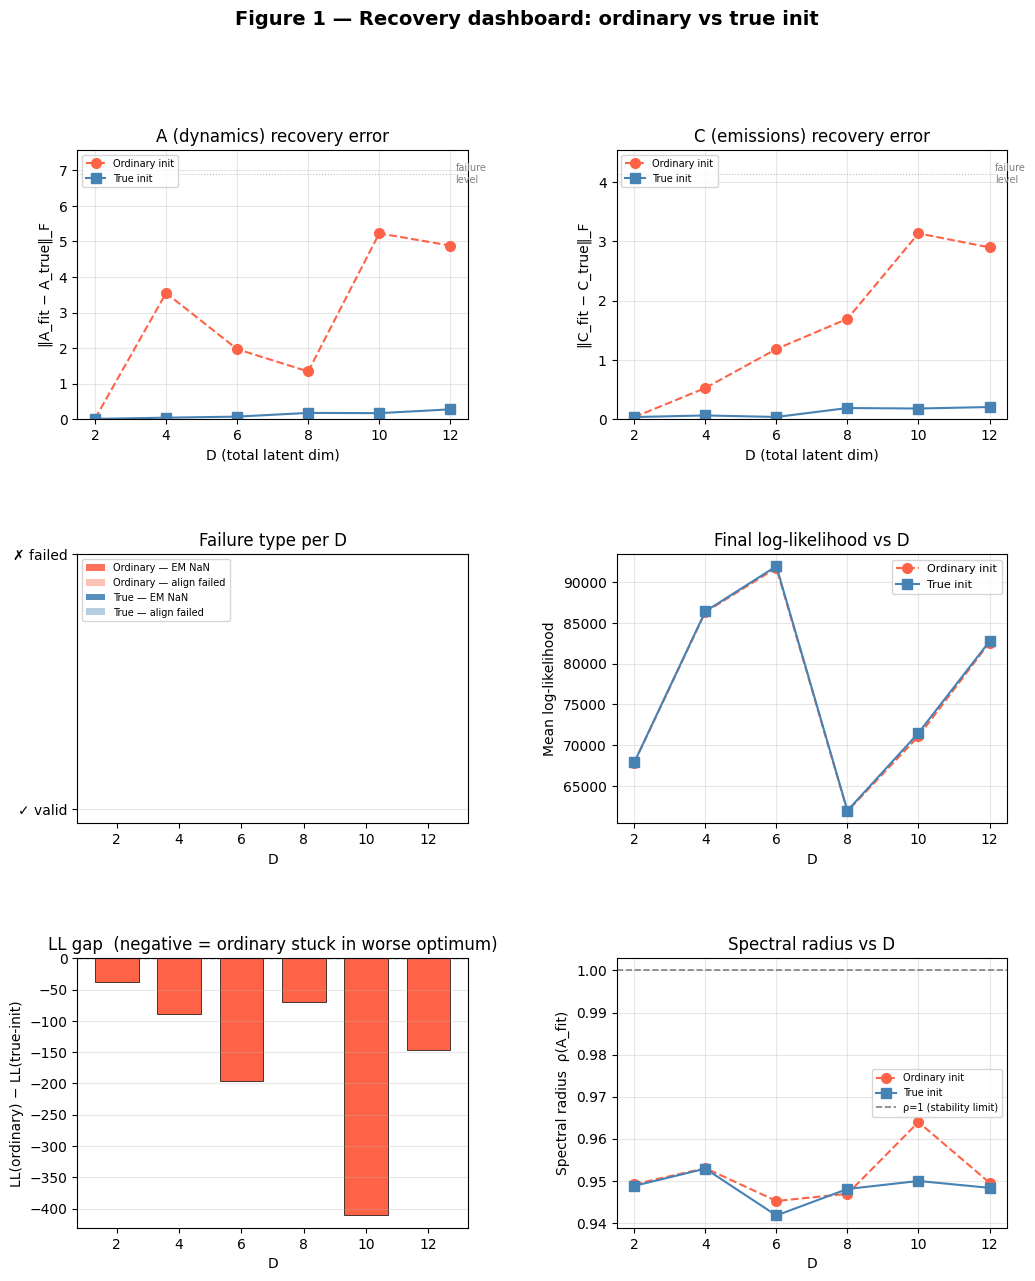

In [5]:
# ============================================================
# SECTION 1 — Figure 1  6-panel recovery dashboard
# ============================================================
Ds_arr    = np.array([r['D']          for r in results_s1])
eA_ord    = np.array([r['err_A_ord']  for r in results_s1], dtype=float)
eA_true   = np.array([r['err_A_true'] for r in results_s1], dtype=float)
eC_ord    = np.array([r['err_C_ord']  for r in results_s1], dtype=float)
eC_true   = np.array([r['err_C_true'] for r in results_s1], dtype=float)
ll_ord_v  = np.array([r['ll_ord']     for r in results_s1], dtype=float)
ll_true_v = np.array([r['ll_true']    for r in results_s1], dtype=float)
rho_ord_v = np.array([r['rho_ord']    for r in results_s1], dtype=float)
rho_true_v= np.array([r['rho_true']   for r in results_s1], dtype=float)
nan_ord_v = [r['nan_ord']  for r in results_s1]
nan_true_v= [r['nan_true'] for r in results_s1]

COL_ORD  = 'tomato'
COL_TRUE = 'steelblue'

def _plot_with_nan(ax, x, y_ord, y_true, ylabel, title):
    valid_o = ~np.isnan(y_ord)
    valid_t = ~np.isnan(y_true)
    all_valid = np.concatenate([y_ord[valid_o], y_true[valid_t]])
    ymax   = float(np.nanmax(all_valid)) * 1.45 if len(all_valid) else 1.0
    fail_y = ymax * 0.91

    if valid_o.any():
        ax.plot(x[valid_o], y_ord[valid_o], 'o--', color=COL_ORD,  ms=7, lw=1.5,
                label='Ordinary init')
    if valid_t.any():
        ax.plot(x[valid_t], y_true[valid_t], 's-',  color=COL_TRUE, ms=7, lw=1.5,
                label='True init')
    if (~valid_o).any():
        ax.scatter(x[~valid_o], np.full((~valid_o).sum(), fail_y),
                   marker='x', s=160, linewidths=2.5, color=COL_ORD,  zorder=5,
                   label='Ordinary — align failed')
    if (~valid_t).any():
        ax.scatter(x[~valid_t], np.full((~valid_t).sum(), fail_y),
                   marker='x', s=160, linewidths=2.5, color=COL_TRUE, zorder=5,
                   label='True — diverged')

    ax.axhline(fail_y, color='gray', ls=':', lw=0.8, alpha=0.5)
    ax.text(x.max() + 0.15, fail_y, 'failure\nlevel', va='center',
            fontsize=7, color='gray')
    ax.set_ylim(0, ymax)
    ax.set_xlabel('D (total latent dim)');  ax.set_ylabel(ylabel)
    ax.set_title(title);  ax.set_xticks(x)
    ax.legend(fontsize=7, loc='upper left');  ax.grid(alpha=0.3)


fig = plt.figure(figsize=(12, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.38)
fig.suptitle('Figure 1 — Recovery dashboard: ordinary vs true init',
             fontsize=14, fontweight='bold')

# ── (0,0)  A recovery error ──────────────────────────────────
_plot_with_nan(fig.add_subplot(gs[0, 0]),
               Ds_arr, eA_ord, eA_true,
               '‖A_fit − A_true‖_F', 'A (dynamics) recovery error')

# ── (0,1)  C recovery error ──────────────────────────────────
_plot_with_nan(fig.add_subplot(gs[0, 1]),
               Ds_arr, eC_ord, eC_true,
               '‖C_fit − C_true‖_F', 'C (emissions) recovery error')

# ── (1,0)  Failure breakdown per D ───────────────────────────
ax = fig.add_subplot(gs[1, 0])
em_nan_o   = np.array([int(n)                              for n in nan_ord_v])
align_nan_o= np.array([int(not n and np.isnan(e))          for n, e in zip(nan_ord_v,  eA_ord)])
em_nan_t   = np.array([int(n)                              for n in nan_true_v])
align_nan_t= np.array([int(not n and np.isnan(e))          for n, e in zip(nan_true_v, eA_true)])
xi = np.arange(len(Ds_arr));  w = 0.35
ax.bar(xi - w/2, em_nan_o,    w, color=COL_ORD,  alpha=0.9, label='Ordinary — EM NaN')
ax.bar(xi - w/2, align_nan_o, w, color=COL_ORD,  alpha=0.4, bottom=em_nan_o,
       label='Ordinary — align failed')
ax.bar(xi + w/2, em_nan_t,    w, color=COL_TRUE, alpha=0.9, label='True — EM NaN')
ax.bar(xi + w/2, align_nan_t, w, color=COL_TRUE, alpha=0.4, bottom=em_nan_t,
       label='True — align failed')
ax.set_xticks(xi);  ax.set_xticklabels(Ds_arr)
ax.set_yticks([0, 1]);  ax.set_yticklabels(['✓ valid', '✗ failed'])
ax.set_xlabel('D');  ax.set_title('Failure type per D')
ax.legend(fontsize=7, loc='upper left');  ax.grid(alpha=0.3, axis='y')

# ── (1,1)  Final LL ───────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
ax.plot(Ds_arr, ll_ord_v,  'o--', color=COL_ORD,  ms=7, label='Ordinary init')
ax.plot(Ds_arr, ll_true_v, 's-',  color=COL_TRUE, ms=7, label='True init')
for d, ll in zip(Ds_arr, ll_true_v):
    if np.isnan(ll):
        ax.annotate('✗', (d, ax.get_ylim()[0]), ha='center', fontsize=11,
                    color=COL_TRUE, va='bottom')
ax.set_xlabel('D');  ax.set_ylabel('Mean log-likelihood')
ax.set_title('Final log-likelihood vs D')
ax.set_xticks(Ds_arr);  ax.legend(fontsize=8);  ax.grid(alpha=0.3)

# ── (2,0)  LL gap ─────────────────────────────────────────────
ax = fig.add_subplot(gs[2, 0])
ll_gap = ll_ord_v - ll_true_v
ax.bar(Ds_arr, ll_gap,
       color=[COL_ORD if g < 0 else COL_TRUE for g in ll_gap],
       edgecolor='k', lw=0.5, width=1.4)
ax.axhline(0, color='gray', lw=1, ls='--')
for d, g in zip(Ds_arr, ll_gap):
    if np.isnan(g):
        ax.annotate('NaN\n(diverged)', (d, 0), ha='center', fontsize=7,
                    color='gray', va='bottom')
ax.set_xlabel('D');  ax.set_ylabel('LL(ordinary) − LL(true-init)')
ax.set_title('LL gap  (negative = ordinary stuck in worse optimum)')
ax.set_xticks(Ds_arr);  ax.grid(alpha=0.3, axis='y')

# ── (2,1)  Spectral radius ────────────────────────────────────
ax = fig.add_subplot(gs[2, 1])
ax.plot(Ds_arr, rho_ord_v,  'o--', color=COL_ORD,  ms=7, label='Ordinary init')
ax.plot(Ds_arr, rho_true_v, 's-',  color=COL_TRUE, ms=7, label='True init')
ax.axhline(1.0, color='gray', ls='--', lw=1.2, label='ρ=1 (stability limit)')
ax.set_xlabel('D');  ax.set_ylabel('Spectral radius  ρ(A_fit)')
ax.set_title('Spectral radius vs D')
ax.set_xticks(Ds_arr);  ax.legend(fontsize=7);  ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fig1_recovery_dashboard.png")
#save_figure(EXP_GROUP, fig, 'fig1_recovery_dashboard', section=1)
plt.show()

  Saved: Exp group 5/Section 1/fig1b_em_convergence_traces.png


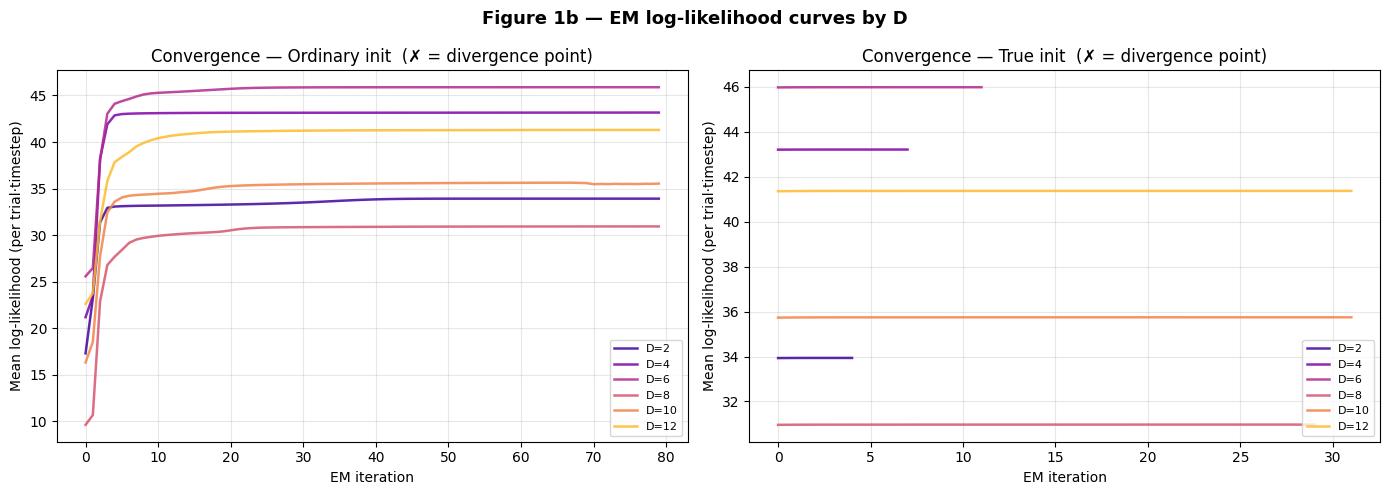

In [6]:
# ============================================================
# SECTION 1 — Figure 1b: EM convergence traces by D
# ============================================================
D_colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(results_s1)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 1b — EM log-likelihood curves by D', fontsize=13, fontweight='bold')

for r, color in zip(results_s1, D_colors):
    label = f"D={r['D']}"
    for ax, key in zip(axes, ('lps_ord', 'lps_true')):
        lps = r[key]
        finite = np.isfinite(lps)
        if finite.any():
            iters = np.where(finite)[0]
            ax.plot(iters, lps[finite], '-', ms=3, color=color,
                    label=label, lw=1.8, alpha=0.85)
        # mark where it diverged
        if not finite.all() and finite.any():
            last_good = np.where(finite)[0][-1]
            ax.scatter([last_good], [lps[last_good]], marker='x',
                       s=120, linewidths=2, color=color, zorder=5)

for ax, title in zip(axes, ['Ordinary init', 'True init']):
    ax.set_xlabel('EM iteration')
    ax.set_ylabel('Mean log-likelihood (per trial·timestep)')
    ax.set_title(f'Convergence — {title}  (✗ = divergence point)')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(alpha=0.3)

plt.tight_layout()
save_figure(EXP_GROUP, fig, 'fig1b_em_convergence_traces', section=1)
plt.show()

  Saved: Exp group 5/Section 1/fig1_recovery_error_vs_D.png


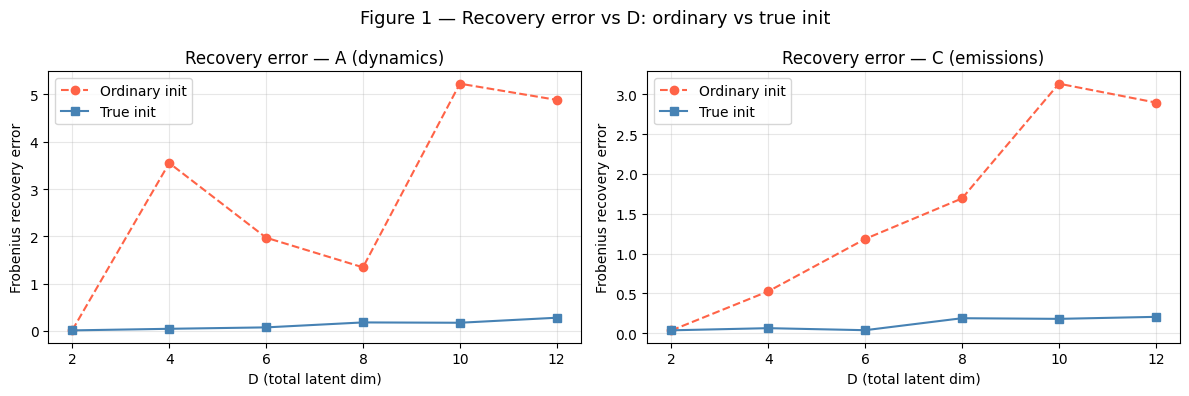

In [7]:
# ============================================================
# SECTION 1 — Figure 1: Recovery error vs D
# ============================================================
Ds       = [r['D']         for r in results_s1]
eA_ord   = [r['err_A_ord'] for r in results_s1]
eA_true  = [r['err_A_true'] for r in results_s1]
eC_ord   = [r['err_C_ord'] for r in results_s1]
eC_true  = [r['err_C_true'] for r in results_s1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, (e_ord, e_true, label) in zip(axes,
        [(eA_ord, eA_true, 'A (dynamics)'),
         (eC_ord, eC_true, 'C (emissions)')]):
    ax.plot(Ds, e_ord,  'o--', color='tomato',    label='Ordinary init')
    ax.plot(Ds, e_true, 's-',  color='steelblue', label='True init')
    ax.set_xlabel('D (total latent dim)')
    ax.set_ylabel('Frobenius recovery error')
    ax.set_title(f'Recovery error — {label}')
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle('Figure 1 — Recovery error vs D: ordinary vs true init', fontsize=13)
plt.tight_layout()
save_figure(EXP_GROUP, fig, 'fig1_recovery_error_vs_D', section=1)
plt.show()


  Saved: Exp group 5/Section 1/fig2_ll_gap_vs_D.png


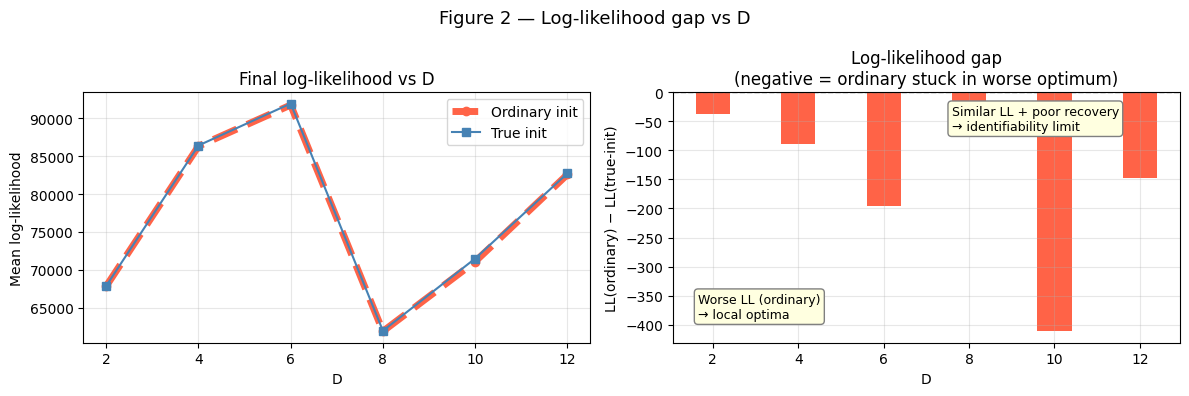

In [8]:
# ============================================================
# SECTION 1 — Figure 2: Log-likelihood gap vs D
# ============================================================
ll_ord_vals  = [r['ll_ord']  for r in results_s1]
ll_true_vals = [r['ll_true'] for r in results_s1]
ll_gap       = [lo - lt for lo, lt in zip(ll_ord_vals, ll_true_vals)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(Ds, ll_ord_vals,  'o--', color='tomato',    label='Ordinary init', linewidth=5)
axes[0].plot(Ds, ll_true_vals, 's-',  color='steelblue', label='True init')
axes[0].set_xlabel('D'); axes[0].set_ylabel('Mean log-likelihood')
axes[0].set_title('Final log-likelihood vs D')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].axhline(0, color='gray', lw=1, ls='--')
axes[1].bar(Ds, ll_gap, color=['tomato' if g < 0 else 'steelblue' for g in ll_gap])
axes[1].set_xlabel('D'); axes[1].set_ylabel('LL(ordinary) − LL(true-init)')
axes[1].set_title('Log-likelihood gap\n(negative = ordinary stuck in worse optimum)')
axes[1].grid(alpha=0.3)

axes[1].annotate('Similar LL + poor recovery\n→ identifiability limit',
                 xy=(0.55, 0.85), xycoords='axes fraction', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='gray'))
axes[1].annotate('Worse LL (ordinary)\n→ local optima',
                 xy=(0.05, 0.1), xycoords='axes fraction', fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='gray'))

fig.suptitle('Figure 2 — Log-likelihood gap vs D', fontsize=13)
plt.tight_layout()
save_figure(EXP_GROUP, fig, 'fig2_ll_gap_vs_D', section=1)
plt.show()


---
## Section 2 — Perturbation Sensitivity Around Truth

**Question:** If you perturb the true parameters in certain directions, does the likelihood barely change?  
Flat curves in Figure 3 indicate **weakly identified directions**.


In [9]:
# ============================================================
# SECTION 2 — Setup: fixed dataset at D=6
# ============================================================
D_S2 = 6
key_s2 = jr.PRNGKey(200)
states_s2, obs_s2, ctds_s2, params_s2 = generate_synthetic_data(
    num_samples=B, num_timesteps=T, state_dim=D_S2, emission_dim=N, key=key_s2
)
ll_true_s2 = eval_ll(ctds_s2, params_s2, obs_s2)
print(f"Ground-truth LL at D={D_S2}: {ll_true_s2:.4f}")


Ground-truth LL at D=6: 111925.1406


In [10]:
# ============================================================
# SECTION 2 — Perturbation families
# ============================================================
def perturb_A_only(params, eps, key):
    """Scale off-diagonal blocks of A by (1+eps) while preserving signs."""
    A = params.dynamics.weights
    dm = params.dynamics.dynamics_mask
    D = A.shape[0]
    diag_mask = jnp.eye(D, dtype=bool)
    # perturb off-diagonal entries in the sign-consistent direction
    dA = eps * jnp.abs(A) * (1 - diag_mask.astype(float))
    A_new = A + dA * jnp.sign(A + 1e-12)  # stays same sign
    dynamics = ParamsCTDSDynamics(weights=A_new, cov=params.dynamics.cov,
                                   dynamics_mask=dm)
    return params._replace(dynamics=dynamics)


def perturb_C_only(params, eps, key):
    """Add eps * Gaussian noise to C, clamp to >= 0."""
    C = params.emissions.weights
    k1 = key
    dC = eps * jr.normal(k1, C.shape)
    C_new = jnp.maximum(0.0, C + dC)
    emissions = params.emissions._replace(weights=C_new)
    return params._replace(emissions=emissions)


def perturb_E_subspace(params, eps, key):
    """Perturb only the E-latent columns of A and rows of C."""
    ctd = params.constraints
    D_e = int(ctd.cell_type_dimensions[0])
    A = params.dynamics.weights
    C = params.emissions.weights
    k1, k2 = jr.split(key)
    dA = jnp.zeros_like(A).at[:, :D_e].set(eps * jr.normal(k1, (A.shape[0], D_e)))
    dA = dA.at[:D_e, :].add(eps * jr.normal(k2, (D_e, A.shape[1])))
    # clamp signs
    dm = params.dynamics.dynamics_mask
    D = A.shape[0]
    A_new = A + dA
    for j in range(D_e):
        od = jnp.arange(D) != j
        A_new = A_new.at[od, j].set(jnp.maximum(A_new[od, j], 0.0))
    C_new = jnp.maximum(0.0, C)  # unchanged but clamped
    dynamics = ParamsCTDSDynamics(weights=A_new, cov=params.dynamics.cov,
                                   dynamics_mask=dm)
    emissions = params.emissions._replace(weights=C_new)
    return params._replace(dynamics=dynamics, emissions=emissions)


def perturb_I_subspace(params, eps, key):
    """Perturb only the I-latent columns of A and rows of C."""
    ctd = params.constraints
    D_e = int(ctd.cell_type_dimensions[0])
    D_i = int(ctd.cell_type_dimensions[1]) if len(ctd.cell_type_dimensions) > 1 else 0
    A = params.dynamics.weights
    C = params.emissions.weights
    k1, k2 = jr.split(key)
    cols_I = slice(D_e, D_e + D_i)
    dA = jnp.zeros_like(A).at[:, cols_I].set(eps * jr.normal(k1, (A.shape[0], D_i)))
    A_new = A + dA
    D = A.shape[0]
    for j in range(D_e, D_e + D_i):
        od = jnp.arange(D) != j
        A_new = A_new.at[od, j].set(jnp.minimum(A_new[od, j], 0.0))
    dynamics = ParamsCTDSDynamics(weights=A_new, cov=params.dynamics.cov,
                                   dynamics_mask=params.dynamics.dynamics_mask)
    return params._replace(dynamics=dynamics)


perturbation_families = {
    'A only':      perturb_A_only,
    'C only':      perturb_C_only,
    'E subspace':  perturb_E_subspace,
    'I subspace':  perturb_I_subspace,
}

eps_values = jnp.logspace(-3, 0, 20)
results_s2 = {name: [] for name in perturbation_families}
param_dists = {name: [] for name in perturbation_families}

for name, fn in perturbation_families.items():
    print(f"Sweeping ε for: {name}")
    key_tmp = jr.PRNGKey(hash(name) % 10000)
    for i, eps in enumerate(eps_values):
        p_pert = fn(params_s2, float(eps), jr.fold_in(key_tmp, i))
        ll_pert = eval_ll(ctds_s2, p_pert, obs_s2)
        delta_ll = ll_pert - ll_true_s2
        # parameter distance
        dA = jnp.linalg.norm(p_pert.dynamics.weights - params_s2.dynamics.weights, 'fro')
        dC = jnp.linalg.norm(p_pert.emissions.weights - params_s2.emissions.weights, 'fro')
        results_s2[name].append(delta_ll)
        param_dists[name].append(float(dA + dC))

print("Section 2 sweep complete.")


Sweeping ε for: A only
Sweeping ε for: C only
Sweeping ε for: E subspace
Sweeping ε for: I subspace
Section 2 sweep complete.


  Saved: Exp group 5/Section 2/fig3_perturbation_sensitivity.png


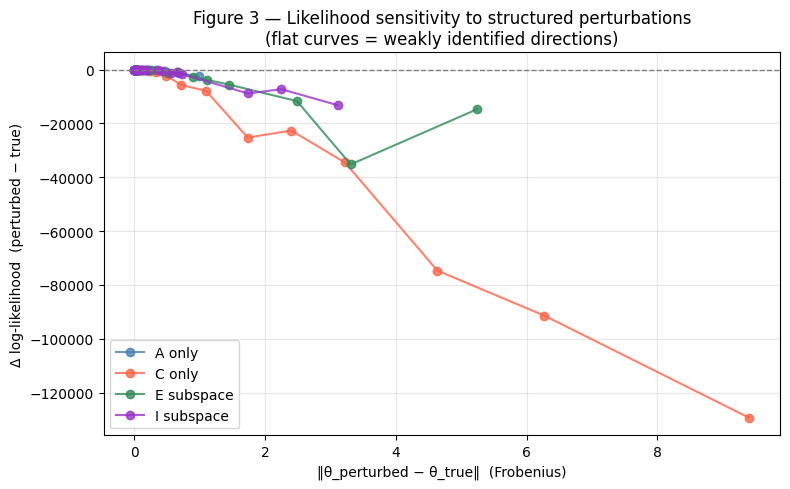

In [11]:
# ============================================================
# SECTION 2 — Figure 3: Δℓ vs ‖θ_perturbed − θ_true‖
# ============================================================
colors = ['steelblue', 'tomato', 'seagreen', 'darkorchid']
fig, ax = plt.subplots(figsize=(8, 5))

for (name, dlls), color in zip(results_s2.items(), colors):
    dists = param_dists[name]
    ax.plot(dists, dlls, 'o-', label=name, color=color, alpha=0.8)

ax.axhline(0, color='gray', lw=1, ls='--')
ax.set_xlabel('‖θ_perturbed − θ_true‖  (Frobenius)')
ax.set_ylabel('Δ log-likelihood  (perturbed − true)')
ax.set_title('Figure 3 — Likelihood sensitivity to structured perturbations\n'
             '(flat curves = weakly identified directions)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
save_figure(EXP_GROUP, fig, 'fig3_perturbation_sensitivity', section=2)
plt.show()


---
## Section 3 — Profile Likelihood / Curvature Proxy

**Question:** Is the objective surface flatter in some directions as D grows?  
Flat curves in Figure 4 → **weak local identifiability** in that direction.


In [12]:
# ============================================================
# SECTION 3 — Setup: directions and sweep
# ============================================================
# Reuse the D=6 dataset from Section 2
D_S3 = D_S2
ctds_s3 = ctds_s2
obs_s3 = obs_s2
params_s3 = params_s2

ctd = params_s3.constraints
D_e3 = int(ctd.cell_type_dimensions[0])
D_i3 = int(ctd.cell_type_dimensions[1]) if len(ctd.cell_type_dimensions) > 1 else 0
D3 = D_S3

def make_direction_A(D, mode, D_e, D_i, key):
    """Return a D×D direction matrix for A for a given mode."""
    U = jnp.zeros((D, D))
    if mode == 'random_feasible':
        U = jr.normal(key, (D, D)) * 0.1
        # clamp off-diagonal to keep Dale sign roughly correct
        col_sign = jnp.concatenate([jnp.ones(D_e), -jnp.ones(D_i)])
        for j in range(D):
            od = jnp.arange(D) != j
            if col_sign[j] == 1:
                U = U.at[od, j].set(jnp.maximum(U[od, j], 0.0))
            else:
                U = U.at[od, j].set(jnp.minimum(U[od, j], 0.0))
    elif mode == 'E_only':
        U = U.at[:, :D_e].set(jr.normal(key, (D, D_e)) * 0.1)
        for j in range(D_e):
            od = jnp.arange(D) != j
            U = U.at[od, j].set(jnp.maximum(U[od, j], 0.0))
    elif mode == 'I_only':
        U = U.at[:, D_e:D_e+D_i].set(jr.normal(key, (D, D_i)) * 0.1)
        for j in range(D_e, D_e + D_i):
            od = jnp.arange(D) != j
            U = U.at[od, j].set(jnp.minimum(U[od, j], 0.0))
    elif mode == 'cross_block':
        # E→I and I→E off-diagonal blocks only
        U = U.at[:D_e, D_e:D_e+D_i].set(jr.normal(key, (D_e, D_i)) * 0.1)
        U = U.at[D_e:D_e+D_i, :D_e].set(jr.normal(key, (D_i, D_e)) * 0.1)
    # normalise
    nrm = jnp.linalg.norm(U, 'fro')
    return U / jnp.maximum(nrm, 1e-8)

direction_names = ['random_feasible', 'E_only', 'I_only', 'cross_block']
t_vals = jnp.linspace(-0.3, 0.3, 40)
profile_results = {}

for dname in direction_names:
    key_d = jr.PRNGKey(hash(dname) % 10000)
    U = make_direction_A(D3, dname, D_e3, D_i3, key_d)
    lls = []
    for t in t_vals:
        A_pert = params_s3.dynamics.weights + float(t) * U
        dynamics_pert = params_s3.dynamics._replace(weights=A_pert)
        p_pert = params_s3._replace(dynamics=dynamics_pert)
        lls.append(eval_ll(ctds_s3, p_pert, obs_s3))
    profile_results[dname] = np.array(lls)
    print(f"  {dname}: LL range [{np.nanmin(lls):.3f}, {np.nanmax(lls):.3f}]")

print("Section 3 sweep complete.")


  random_feasible: LL range [111649.257, 111925.314]
  E_only: LL range [111059.523, 111924.685]
  I_only: LL range [111678.831, 111925.019]
  cross_block: LL range [111563.665, 111925.125]
Section 3 sweep complete.


  Saved: Exp group 5/Section 3/fig4_profile_likelihood.png


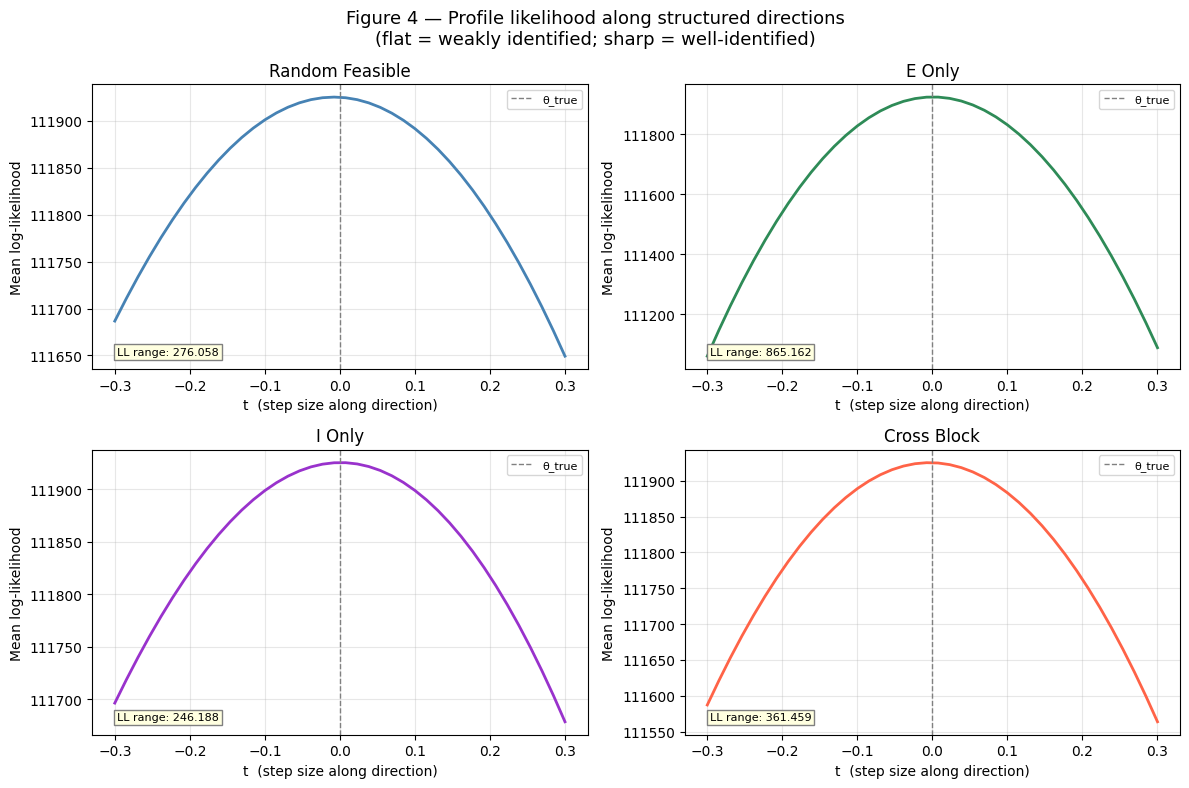

In [13]:
# ============================================================
# SECTION 3 — Figure 4: Profile likelihood small multiples
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colors_s3 = ['steelblue', 'seagreen', 'darkorchid', 'tomato']

for ax, dname, color in zip(axes.flat, direction_names, colors_s3):
    lls = profile_results[dname]
    ax.plot(t_vals, lls, '-', color=color, lw=2)
    ax.axvline(0, color='gray', lw=1, ls='--', label='θ_true')
    ax.set_xlabel('t  (step size along direction)')
    ax.set_ylabel('Mean log-likelihood')
    ax.set_title(dname.replace('_', ' ').title())
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    # annotate curvature: LL range as proxy
    ll_range = np.nanmax(lls) - np.nanmin(lls)
    ax.text(0.05, 0.05, f'LL range: {ll_range:.3f}',
            transform=ax.transAxes, fontsize=8,
            bbox=dict(fc='lightyellow', ec='gray', pad=2))

fig.suptitle('Figure 4 — Profile likelihood along structured directions\n'
             '(flat = weakly identified; sharp = well-identified)', fontsize=13)
plt.tight_layout()
save_figure(EXP_GROUP, fig, 'fig4_profile_likelihood', section=3)
plt.show()


---
## Section 4 — E/I Label-Flip Symmetry Test

**Question:** Is the observed E-vs-I recovery asymmetry structural or just an unequal-SNR artefact?

**Interpretation:**
- If asymmetry **reverses** under the flip → it was an SNR / construction artefact.
- If asymmetry **persists** → the inference procedure genuinely favours one group.


In [14]:
# ============================================================
# SECTION 4 — Build the flipped model
# ============================================================
D_S4 = 6
key_s4 = jr.PRNGKey(400)
states_s4, obs_s4, ctds_s4, params_s4 = generate_synthetic_data(
    num_samples=B, num_timesteps=T, state_dim=D_S4, emission_dim=N, key=key_s4
)

def flip_EI_params(params, ctds):
    """
    Swap E and I blocks in A, C, Q, and constraints.
    Assumes K=2 with E first, I second.
    Returns a new ParamsCTDS and a new CTDS with swapped cell types.
    """
    ctd = params.constraints
    D_e = int(ctd.cell_type_dimensions[0])
    D_i = int(ctd.cell_type_dimensions[1])
    D   = D_e + D_i
    N_obs = params.emissions.weights.shape[0]

    # Build permutation: put I dims first, then E dims
    perm = jnp.concatenate([jnp.arange(D_e, D_e+D_i), jnp.arange(D_e)])

    A_flip = params.dynamics.weights[perm][:, perm]
    Q_flip = params.dynamics.cov[perm][:, perm]
    C_flip = params.emissions.weights[:, perm]

    # Flip neuron assignment (assumes neurons 0..N_e-1 are E, rest I)
    N_e_neurons = int(jnp.sum(ctd.cell_type_mask == ctd.cell_types[0]))
    cell_type_mask_flip = jnp.concatenate([
        jnp.ones(N - N_e_neurons, dtype=int),   # formerly I → now type 0
        jnp.zeros(N_e_neurons, dtype=int),       # formerly E → now type 1
    ])
    cell_sign_flip       = jnp.array([-1,  1])   # I-sign first now
    cell_type_dims_flip  = jnp.array([D_i, D_e])

    constraints_flip = ParamsCTDSConstraints(
        cell_types=ctd.cell_types,
        cell_sign=cell_sign_flip,
        cell_type_dimensions=cell_type_dims_flip,
        cell_type_mask=cell_type_mask_flip,
    )
    dynamics_flip  = ParamsCTDSDynamics(
        weights=A_flip, cov=Q_flip,
        dynamics_mask=jnp.repeat(cell_sign_flip, cell_type_dims_flip)
    )
    emissions_flip = params.emissions._replace(weights=C_flip)
    params_flip = ParamsCTDS(
        initial=params.initial,
        dynamics=dynamics_flip,
        emissions=emissions_flip,
        constraints=constraints_flip,
        observations=params.observations,
    )
    ctds_flip = CTDS(
        emission_dim=ctds.emission_dim,
        cell_types=ctd.cell_types,
        cell_sign=cell_sign_flip,
        cell_type_dimensions=cell_type_dims_flip,
        cell_type_mask=cell_type_mask_flip,
        region_identity=None,
        inputs_dim=None,
        state_dim=D,
    )
    return params_flip, ctds_flip, perm


params_s4_flip, ctds_s4_flip, perm_s4 = flip_EI_params(params_s4, ctds_s4)
print("Flipped model built.")
print("  Original E dims:", int(params_s4.constraints.cell_type_dimensions[0]))
print("  Flipped  I dims:", int(params_s4_flip.constraints.cell_type_dimensions[1]))


Flipped model built.
  Original E dims: 3
  Flipped  I dims: 3


In [15]:
# ============================================================
# SECTION 4 — Fit original and flipped models
# ============================================================
def blockwise_errors(A_true, A_fit, C_true, C_fit, D_e):
    """Return separate Frobenius errors for E and I blocks of A/C."""
    err_A_E = float(jnp.linalg.norm(A_fit[:D_e, :D_e] - A_true[:D_e, :D_e], 'fro'))
    err_A_I = float(jnp.linalg.norm(A_fit[D_e:, D_e:] - A_true[D_e:, D_e:], 'fro'))
    err_C_E = float(jnp.linalg.norm(C_fit[:, :D_e] - C_true[:, :D_e], 'fro'))
    err_C_I = float(jnp.linalg.norm(C_fit[:, D_e:] - C_true[:, D_e:], 'fro'))
    return err_A_E, err_A_I, err_C_E, err_C_I

D_e_s4 = int(params_s4.constraints.cell_type_dimensions[0])

# Original model
key_orig = jr.PRNGKey(401)
p_orig_init = ctds_s4.initialize(obs_s4) 
pf_orig, _, _ = fit_ctds(ctds_s4, p_orig_init, obs_s4)
eAE_o, eAI_o, eCE_o, eCI_o = blockwise_errors(
    params_s4.dynamics.weights, pf_orig.dynamics.weights,
    params_s4.emissions.weights, pf_orig.emissions.weights, D_e_s4
)
print(f"Original — err_A_E={eAE_o:.4f}, err_A_I={eAI_o:.4f}, "
      f"err_C_E={eCE_o:.4f}, err_C_I={eCI_o:.4f}")

# Flipped model: generate matching observations from flipped truth
key_flip = jr.PRNGKey(402)
states_flip, obs_flip = jax.vmap(lambda k: ctds_s4_flip.sample(params_s4_flip, k, T))(jr.split(key_flip, B))
p_flip_obs = params_s4_flip._replace(observations=obs_flip)
p_flip_init = ctds_s4_flip.initialize(obs_flip)
pf_flip, _, _ = fit_ctds(ctds_s4_flip, p_flip_init, obs_flip)
D_e_flip = int(params_s4_flip.constraints.cell_type_dimensions[0])  # D_i originally
eAE_f, eAI_f, eCE_f, eCI_f = blockwise_errors(
    params_s4_flip.dynamics.weights, pf_flip.dynamics.weights,
    params_s4_flip.emissions.weights, pf_flip.emissions.weights, D_e_flip
)
print(f"Flipped  — err_A_E={eAE_f:.4f}, err_A_I={eAI_f:.4f}, "
      f"err_C_E={eCE_f:.4f}, err_C_I={eCI_f:.4f}")


Y shape (10000, 20)


Running for 80 iterations:   0%|          | 0/80 [00:00<?, ?it/s]

Original — err_A_E=0.7590, err_A_I=0.6356, err_C_E=2.0737, err_C_I=1.6889
Y shape (10000, 20)


Running for 80 iterations:   0%|          | 0/80 [00:00<?, ?it/s]

Flipped  — err_A_E=0.8035, err_A_I=0.6692, err_C_E=1.6764, err_C_I=2.1679


  Saved: Exp group 5/Section 4/fig5_EI_label_flip.png


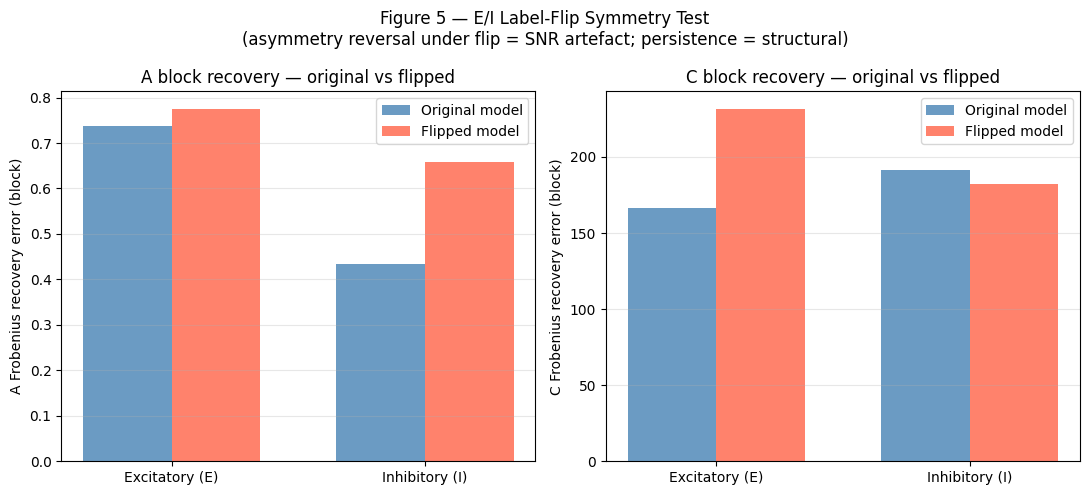

In [ ]:
# ============================================================
# SECTION 4 — Figure 5: Paired bar chart
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
width = 0.35
x = np.arange(2)
labels_x = ['Excitatory (E)', 'Inhibitory (I)']

for ax, (vals_orig, vals_flip, mtx) in zip(axes, [
    ([eAE_o, eAI_o], [eAE_f, eAI_f], 'A'),
    ([eCE_o, eCI_o], [eCE_f, eCI_f], 'C'),
]):
    bars1 = ax.bar(x - width/2, vals_orig, width, label='Original model', color='steelblue', alpha=0.8)
    bars2 = ax.bar(x + width/2, vals_flip, width, label='Flipped model',  color='tomato',    alpha=0.8)
    ax.set_xticks(x); ax.set_xticklabels(labels_x)
    ax.set_ylabel(f'{mtx} Frobenius recovery error (block)')
    ax.set_title(f'{mtx} block recovery — original vs flipped')
    ax.legend(); ax.grid(alpha=0.3, axis='y')

fig.suptitle('Figure 5 — E/I Label-Flip Symmetry Test\n'
             '(asymmetry reversal under flip = SNR artefact; persistence = structural)', fontsize=12)
plt.tight_layout()
save_figure(EXP_GROUP, fig, 'fig5_EI_label_flip', section=4)
plt.show()


---
## Section 5 — (D_E, D_I) Dimension Ratio Grid

**Question:** Does weak identifiability worsen primarily with total dimension, or specifically with inhibitory dimension?


In [ ]:
# ============================================================
# SECTION 5 — Grid sweep
# ============================================================
DE_vals = [1, 2, 3, 4]
DI_vals = [1, 2, 3, 4]
results_s5 = {}

for D_e, D_i in iproduct(DE_vals, DI_vals):
    D_tot = D_e + D_i
    key_g = jr.PRNGKey(D_e * 1000 + D_i)
    print(f"  D_e={D_e}, D_i={D_i}, D={D_tot}", end=' ... ')

    # Generate data with explicit E/I split
    try:
        # Use generate_CTDS_Params with cell_type_dimensions override
        from ctds.simulation_utils import make_A_true, make_Q_true
        ctd_params_g = generate_CTDS_Params(
            N=N, T=T, D=D_tot, K=2,
            excitatory_fraction=D_e / D_tot,
            seed=key_g,
        )
        ctds_g = CTDS(
            emission_dim=N,
            cell_types=ctd_params_g.constraints.cell_types,
            cell_sign=ctd_params_g.constraints.cell_sign,
            cell_type_dimensions=ctd_params_g.constraints.cell_type_dimensions,
            cell_type_mask=ctd_params_g.constraints.cell_type_mask,
            region_identity=None, inputs_dim=None, state_dim=D_tot,
        )
        keys_g = jr.split(key_g, B)
        states_g, obs_g = jax.vmap(lambda k: ctds_g.sample(ctd_params_g, k, T))(keys_g)

        # Ordinary-init fit
        p_init_g = ctds_g.initialize(obs_g) 
        pf_g, lps_g, nan_g = fit_ctds(ctds_g, p_init_g, obs_g)

        # True-init fit for LL gap
        p_true_g = ctd_params_g
        pf_true_g, lps_true_g, _ = fit_ctds(ctds_g, p_true_g, obs_g)

        err_A_g, err_C_g = align_and_error(
            ctd_params_g.dynamics.weights, pf_g.dynamics.weights,
            ctd_params_g.emissions.weights, pf_g.emissions.weights, ctd_params_g
        )
        ll_ord_g  = eval_ll(ctds_g, pf_g,      obs_g)
        ll_true_g = eval_ll(ctds_g, pf_true_g,  obs_g)
        rho_g = spectral_radius(pf_g.dynamics.weights)
        print(f"err_A={err_A_g:.3f}, rho={rho_g:.3f}, nan={nan_g}")

        results_s5[(D_e, D_i)] = dict(
            err_A=err_A_g, err_C=err_C_g,
            nan=float(nan_g), rho=rho_g,
            ll_gap=ll_ord_g - ll_true_g,
        )
    except Exception as ex:
        print(f"FAILED: {ex}")
        results_s5[(D_e, D_i)] = dict(err_A=np.nan, err_C=np.nan,
                                       nan=1.0, rho=np.nan, ll_gap=np.nan)

print("Section 5 sweep complete.")


  D_e=1, D_i=1, D=2 ... Y shape (2500, 20)
Iteration 1: ll=-18.464533943340392  rel_change=0.0007804316887534953
Iteration 2: ll=-16.93123051747394  rel_change=0.08304046181568919
Iteration 3: ll=-16.292976129432695  rel_change=0.03769686954427383
Iteration 4: ll=-16.271812418608537  rel_change=0.001298946899328392
Iteration 5: ll=-16.26680007859005  rel_change=0.000308038212925359
Iteration 6: ll=-16.26366586955801  rel_change=0.00019267520452084853
Iteration 7: ll=-16.261297701496  rel_change=0.000145610963789137
Iteration 8: ll=-16.25927820063921  rel_change=0.00012419063311330764
Iteration 9: ll=-16.257422241519468  rel_change=0.00011414769443255656
Iteration 10: ll=-16.255678393126185  rel_change=0.00010726475374614732
Iteration 11: ll=-16.25405439709481  rel_change=9.99033071460662e-05
Iteration 12: ll=-16.25256965327202  rel_change=9.134605966715529e-05
Iteration 13: ll=-16.25123508023293  rel_change=8.211458665051409e-05
Iteration 14: ll=-16.25004904844964  rel_change=7.2981024

  Saved: Exp group 5/Section 5/fig6_DE_DI_heatmap.png


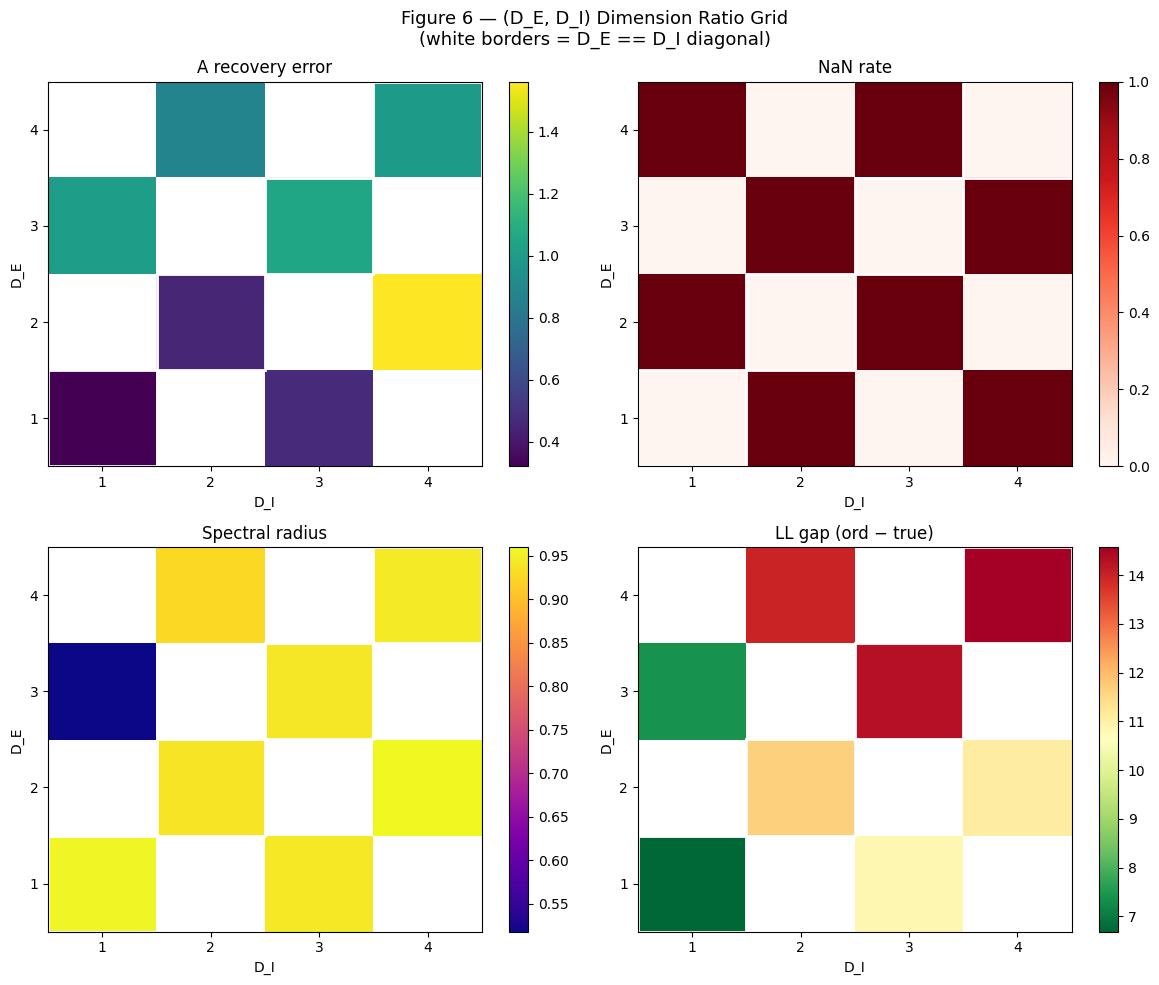

In [ ]:
# ============================================================
# SECTION 5 — Figure 6: 2×2 heatmap panel
# ============================================================
metrics = [('err_A', 'A recovery error'), ('nan', 'NaN rate'),
           ('rho',   'Spectral radius'),   ('ll_gap', 'LL gap (ord − true)')]
cmaps   = ['viridis', 'Reds', 'plasma', 'RdYlGn_r']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (key_m, title_m), cmap in zip(axes.flat, metrics, cmaps):
    mat = np.full((len(DE_vals), len(DI_vals)), np.nan)
    for i, De in enumerate(DE_vals):
        for j, Di in enumerate(DI_vals):
            val = results_s5.get((De, Di), {}).get(key_m, np.nan)
            mat[i, j] = val
    im = ax.imshow(mat, origin='lower', cmap=cmap, aspect='auto')
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(len(DI_vals))); ax.set_xticklabels(DI_vals)
    ax.set_yticks(range(len(DE_vals))); ax.set_yticklabels(DE_vals)
    ax.set_xlabel('D_I'); ax.set_ylabel('D_E')
    ax.set_title(title_m)
    # Mark diagonal
    diag_idx = [(i, j) for i, De in enumerate(DE_vals) for j, Di in enumerate(DI_vals) if De == Di]
    for (i, j) in diag_idx:
        ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False, edgecolor='white', lw=2))

fig.suptitle('Figure 6 — (D_E, D_I) Dimension Ratio Grid\n'
             '(white borders = D_E == D_I diagonal)', fontsize=13)
plt.tight_layout()
save_figure(EXP_GROUP, fig, 'fig6_DE_DI_heatmap', section=5)
plt.show()


---
## Section 6 — Multi-Start EM

**Question:** As D grows, does the optimizer land in many different solutions?

**Interpretation:**
- Wide LL spread → **local optima / optimisation instability**.
- Similar LL but very different parameters → **near-equivalent solutions / weak identifiability**.


In [ ]:
# ============================================================
# SECTION 6 — Multi-start loop (D=4 and D=10)
# ============================================================
N_RESTARTS = 15
D_vals_s6  = [4, 10]
results_s6  = {D: [] for D in D_vals_s6}

for D in D_vals_s6:
    print(f"\n── Multi-start: D={D} ──────────────")
    key_data = jr.PRNGKey(D * 600)
    states_m, obs_m, ctds_m, params_m = generate_synthetic_data(
        num_samples=B, num_timesteps=T, state_dim=D, emission_dim=N, key=key_data
    )
    A_true_m = params_m.dynamics.weights
    C_true_m = params_m.emissions.weights

    for restart in range(N_RESTARTS):
        key_r = jr.PRNGKey(D * 600 + restart + 1)
        p_init_r = ctds_m.initialize(obs_m)
        pf_r, lps_r, nan_r = fit_ctds(ctds_m, p_init_r, obs_m)
        ll_r = eval_ll(ctds_m, pf_r, obs_m)
        eA_r, eC_r = align_and_error(A_true_m, pf_r.dynamics.weights,
                                      C_true_m, pf_r.emissions.weights, params_m)
        rho_r = spectral_radius(pf_r.dynamics.weights)
        results_s6[D].append(dict(ll=ll_r, err_A=eA_r, err_C=eC_r,
                                   rho=rho_r, nan=nan_r,
                                   A_fit=np.array(pf_r.dynamics.weights)))
        print(f"  restart {restart+1:2d}: ll={ll_r:.3f}, err_A={eA_r:.4f}, rho={rho_r:.3f}, nan={nan_r}")

print("Section 6 complete.")



── Multi-start: D=4 ──────────────
Y shape (2500, 20)
Iteration 1: ll=-10.980156001507657  rel_change=4.185054993577646e-06
Iteration 2: ll=-10.978256787497994  rel_change=0.00017296785304341328
Iteration 3: ll=-10.904362330023053  rel_change=0.006730982787640006
Iteration 4: ll=-10.06008110887984  rel_change=0.07742600581224698
Iteration 5: ll=-9.672852610158937  rel_change=0.03849158814227696
Iteration 6: ll=-9.60765338307907  rel_change=0.006740434255288036
Iteration 7: ll=-9.565757663055036  rel_change=0.004360661064003349
Iteration 8: ll=-9.53498434076383  rel_change=0.003217029259486729
Iteration 9: ll=-9.512856228646994  rel_change=0.0023207287317959244
Iteration 10: ll=-9.497378580352255  rel_change=0.0016270243050799551
Iteration 11: ll=-9.48677265880897  rel_change=0.001116720940789374
Iteration 12: ll=-9.47958053022069  rel_change=0.0007581217392830443
Iteration 13: ll=-9.47470821587234  rel_change=0.0005139799522582275
Iteration 14: ll=-9.47134491701712  rel_change=0.00035

  Saved: Exp group 5/Section 6/fig7_multistart_scatter.png


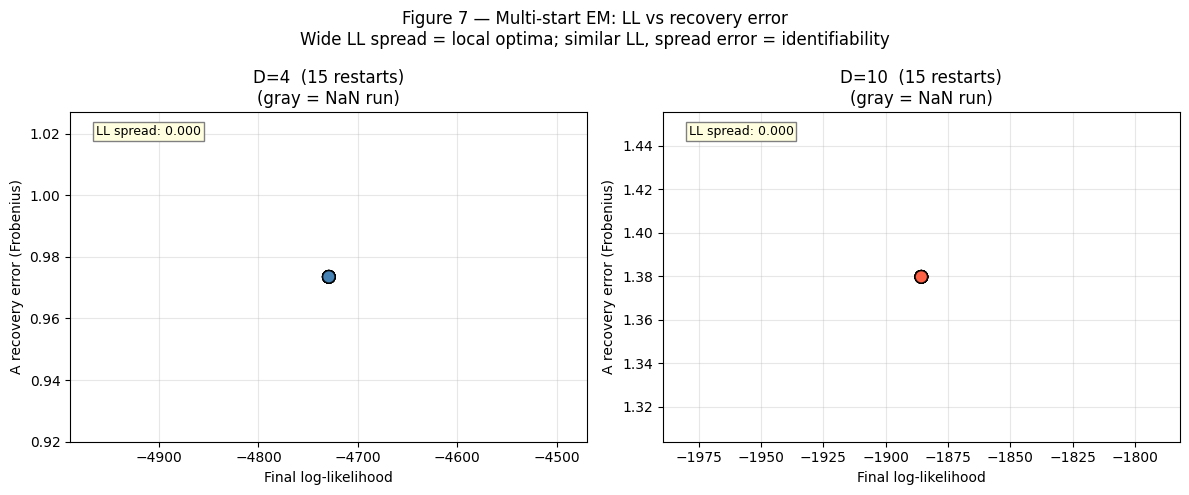

In [ ]:
# ============================================================
# SECTION 6 — Figure 7: Scatterplot LL vs recovery error
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
colors_s6 = {4: 'steelblue', 10: 'tomato'}

for ax, D in zip(axes, D_vals_s6):
    rs = results_s6[D]
    lls    = [r['ll']    for r in rs]
    err_As = [r['err_A'] for r in rs]
    nans   = [r['nan']   for r in rs]
    sc = ax.scatter(lls, err_As,
                    c=['gray' if n else colors_s6[D] for n in nans],
                    s=80, edgecolors='k', alpha=0.8, zorder=3)
    ax.set_xlabel('Final log-likelihood')
    ax.set_ylabel('A recovery error (Frobenius)')
    ax.set_title(f'D={D}  ({N_RESTARTS} restarts)\n'
                 '(gray = NaN run)')
    ax.grid(alpha=0.3)
    # annotate spread
    ll_spread = np.nanmax(lls) - np.nanmin(lls)
    ax.text(0.05, 0.93, f'LL spread: {ll_spread:.3f}',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(fc='lightyellow', ec='gray', pad=2))

fig.suptitle('Figure 7 — Multi-start EM: LL vs recovery error\n'
             'Wide LL spread = local optima; similar LL, spread error = identifiability', fontsize=12)
plt.tight_layout()
save_figure(EXP_GROUP, fig, 'fig7_multistart_scatter', section=6)
plt.show()


  Saved: Exp group 5/Section 6/fig8_multistart_boxplot.png


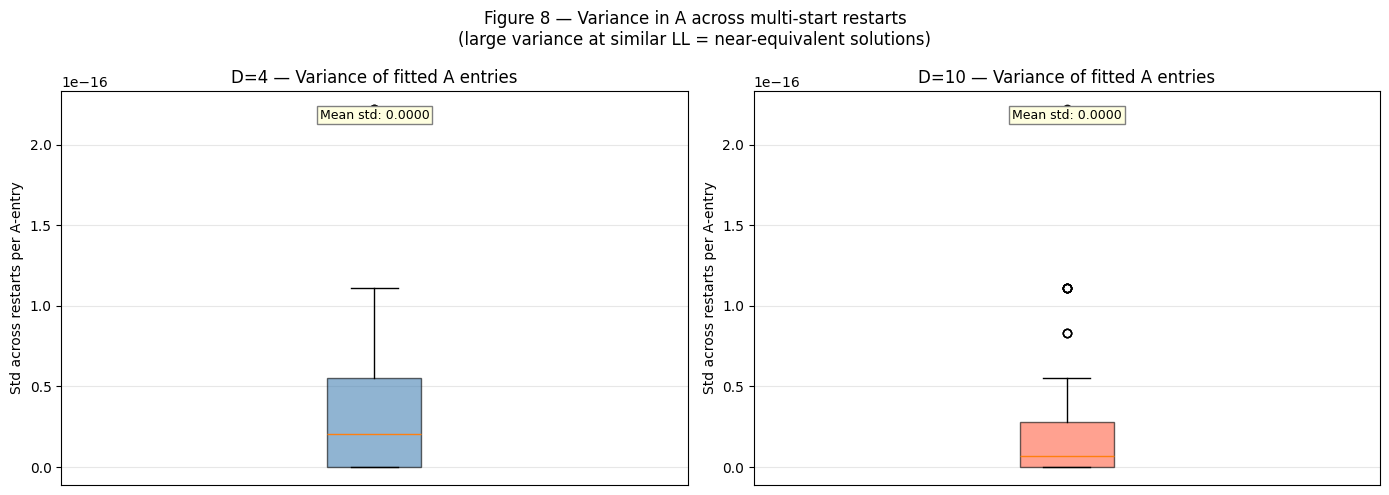

In [ ]:
# ============================================================
# SECTION 6 — Figure 8: Boxplot of A-entry variance across restarts
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, D in zip(axes, D_vals_s6):
    rs = results_s6[D]
    As = np.stack([r['A_fit'] for r in rs], axis=0)  # (n_restarts, D, D)
    A_std = np.std(As, axis=0).ravel()                 # (D*D,)
    ax.boxplot(A_std, vert=True, patch_artist=True,
               boxprops=dict(facecolor=colors_s6[D], alpha=0.6))
    ax.set_ylabel('Std across restarts per A-entry')
    ax.set_title(f'D={D} — Variance of fitted A entries')
    ax.set_xticks([]); ax.grid(alpha=0.3, axis='y')
    ax.text(0.5, 0.93, f'Mean std: {np.nanmean(A_std):.4f}',
            transform=ax.transAxes, ha='center', fontsize=9,
            bbox=dict(fc='lightyellow', ec='gray', pad=2))

fig.suptitle('Figure 8 — Variance in A across multi-start restarts\n'
             '(large variance at similar LL = near-equivalent solutions)', fontsize=12)
plt.tight_layout()
save_figure(EXP_GROUP, fig, 'fig8_multistart_boxplot', section=6)
plt.show()


---
## Section 7 — Recovery vs Sample Size

**Question:** Does the problem disappear as T or number of trials increases?

**Interpretation:**
- Recovery improves strongly with more data → **finite-sample / low SNR**.
- Recovery stays bad even with lots of data → **structural / optimisation issue**.


In [ ]:
# ============================================================
# SECTION 7 — Sweep over data sizes
# ============================================================
D_S7 = 6
# (T, B) pairs — total data = T * B
data_configs = [(50, 3), (100, 5), (200, 10), (500, 10), (1000, 10)]
key_s7 = jr.PRNGKey(700)

# Generate the fixed true model at largest T to sample from
_, _, ctds_s7, params_s7 = generate_synthetic_data(
    num_samples=1, num_timesteps=data_configs[-1][0],
    state_dim=D_S7, emission_dim=N, key=key_s7
)
A_true_s7 = params_s7.dynamics.weights
C_true_s7 = params_s7.emissions.weights

results_s7 = []

for T_cfg, B_cfg in data_configs:
    total_data = T_cfg * B_cfg
    print(f"\n  T={T_cfg}, B={B_cfg}, total={total_data}")
    keys_cfg = jr.split(jr.PRNGKey(700 + T_cfg), B_cfg)
    states_cfg, obs_cfg = jax.vmap(lambda k: ctds_s7.sample(params_s7, k, T_cfg))(keys_cfg)

    # Ordinary-init
    key_oi = jr.PRNGKey(700 + T_cfg + 1)
    p_oi =ctds_s7.initialize(obs_cfg)
    pf_oi, _, _ = fit_ctds(ctds_s7, p_oi, obs_cfg, num_iters=NUM_EM_ITERS)
    eA_oi, eC_oi = align_and_error(A_true_s7, pf_oi.dynamics.weights,
                                    C_true_s7, pf_oi.emissions.weights, params_s7)

    # True-init
    key_ti = jr.PRNGKey(700 + T_cfg + 2)
    p_ti = params_s7
    pf_ti, _, _ = fit_ctds(ctds_s7, p_ti, obs_cfg, num_iters=NUM_EM_ITERS)
    eA_ti, eC_ti = align_and_error(A_true_s7, pf_ti.dynamics.weights,
                                    C_true_s7, pf_ti.emissions.weights, params_s7)

    print(f"  Ordinary: err_A={eA_oi:.4f}, err_C={eC_oi:.4f}")
    print(f"  True-init: err_A={eA_ti:.4f}, err_C={eC_ti:.4f}")

    results_s7.append(dict(
        total_data=total_data,
        eA_oi=eA_oi, eC_oi=eC_oi,
        eA_ti=eA_ti, eC_ti=eC_ti,
    ))

print("Section 7 complete.")



  T=50, B=3, total=150
Y shape (150, 20)
Iteration 1: ll=-11.500052847980742  rel_change=0.0006707671451100267
Iteration 2: ll=-9.655558516551896  rel_change=0.160390074359764
Iteration 3: ll=-7.386706298186376  rel_change=0.23497886885322827
Iteration 4: ll=-6.67425755503448  rel_change=0.09645012464172578
Iteration 5: ll=-6.498443300777657  rel_change=0.026342144097241768
Iteration 6: ll=-6.427376761498123  rel_change=0.010935932805789013
Iteration 7: ll=-6.382985242639193  rel_change=0.00690663088631247
Iteration 8: ll=-6.346750056735759  rel_change=0.005676839993515471
Iteration 9: ll=-6.313353804238509  rel_change=0.005261945436437469
Iteration 10: ll=-6.284596755010751  rel_change=0.004554956069221283
Iteration 11: ll=-6.263289221107275  rel_change=0.0033904377216386053
Iteration 12: ll=-6.2465055661874676  rel_change=0.0026796870346089815
Iteration 13: ll=-6.231522153773576  rel_change=0.0023986871147600943
Iteration 14: ll=-6.217788918651882  rel_change=0.0022038331538911694
I

  Saved: Exp group 5/Section 7/fig9_recovery_vs_data.png


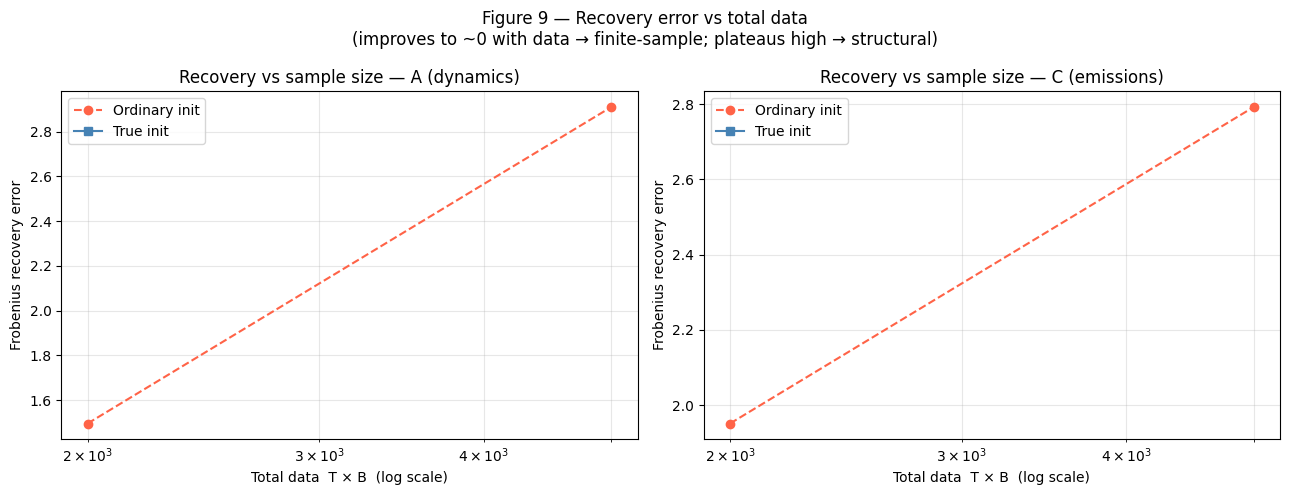

In [ ]:
# ============================================================
# SECTION 7 — Figure 9: Recovery error vs total data
# ============================================================
total_datas = [r['total_data'] for r in results_s7]
eA_oi_vals  = [r['eA_oi']     for r in results_s7]
eA_ti_vals  = [r['eA_ti']     for r in results_s7]
eC_oi_vals  = [r['eC_oi']     for r in results_s7]
eC_ti_vals  = [r['eC_ti']     for r in results_s7]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (oi_vals, ti_vals, label) in zip(axes, [
    (eA_oi_vals, eA_ti_vals, 'A (dynamics)'),
    (eC_oi_vals, eC_ti_vals, 'C (emissions)'),
]):
    ax.semilogx(total_datas, oi_vals, 'o--', color='tomato',    label='Ordinary init')
    ax.semilogx(total_datas, ti_vals, 's-',  color='steelblue', label='True init')
    ax.set_xlabel('Total data  T × B  (log scale)')
    ax.set_ylabel('Frobenius recovery error')
    ax.set_title(f'Recovery vs sample size — {label}')
    ax.legend(); ax.grid(alpha=0.3, which='both')

fig.suptitle('Figure 9 — Recovery error vs total data\n'
             '(improves to ~0 with data → finite-sample; plateaus high → structural)', fontsize=12)
plt.tight_layout()
save_figure(EXP_GROUP, fig, 'fig9_recovery_vs_data', section=7)
plt.show()


---
## Summary


In [ ]:
# ============================================================
# SUMMARY — Collect and print key findings
# ============================================================

print("=" * 65)
print("WEAK IDENTIFIABILITY EXPERIMENT SUMMARY")
print("=" * 65)

summary_rows = [
    ("1", "True-init vs ordinary-init",
     "True-init err (large D): {:.3f} | Ordinary-init err: {:.3f}".format(
         results_s1[-1]['err_A_true'], results_s1[-1]['err_A_ord'])),
    ("2", "Perturbation sensitivity",
     "Flattest family: {}  (min |Δℓ|/‖Δθ‖)".format(
         min(results_s2, key=lambda n: np.nanmean(np.abs(results_s2[n]))))),
    ("3", "Profile likelihood",
     "Flattest direction: {}  (smallest LL range)".format(
         min(profile_results, key=lambda n: np.nanmax(profile_results[n]) - np.nanmin(profile_results[n])))),
    ("4", "E/I label-flip symmetry",
     "Original E err={:.3f}, I err={:.3f} | Flipped E err={:.3f}, I err={:.3f}".format(
         eAE_o, eAI_o, eAE_f, eAI_f)),
    ("5", "(D_E, D_I) dimension grid",
     "See Figure 6 heatmaps for worst-case cell"),
    ("6", "Multi-start EM",
     "D=4 LL spread={:.3f} | D=10 LL spread={:.3f}".format(
         np.nanmax([r['ll'] for r in results_s6[4]]) - np.nanmin([r['ll'] for r in results_s6[4]]),
         np.nanmax([r['ll'] for r in results_s6[10]]) - np.nanmin([r['ll'] for r in results_s6[10]]))),
    ("7", "Recovery vs sample size",
     "True-init err at min data={:.3f} vs max data={:.3f}".format(
         results_s7[0]['eA_ti'], results_s7[-1]['eA_ti'])),
]

print(f"{'#':<4} {'Experiment':<30} {'Finding'}")
print("-" * 65)
for num, name, finding in summary_rows:
    print(f"{num:<4} {name:<30} {finding}")
print("=" * 65)


WEAK IDENTIFIABILITY EXPERIMENT SUMMARY
#    Experiment                     Finding
-----------------------------------------------------------------
1    True-init vs ordinary-init     True-init err (large D): nan | Ordinary-init err: 1.707
2    Perturbation sensitivity       Flattest family: A only  (min |Δℓ|/‖Δθ‖)
3    Profile likelihood             Flattest direction: random_feasible  (smallest LL range)
4    E/I label-flip symmetry        Original E err=0.737, I err=0.435 | Flipped E err=0.775, I err=0.658
5    (D_E, D_I) dimension grid      See Figure 6 heatmaps for worst-case cell
6    Multi-start EM                 D=4 LL spread=0.000 | D=10 LL spread=0.000
7    Recovery vs sample size        True-init err at min data=nan vs max data=nan
